### **Identificacion y generacion de features IEEE-Fraude**

Identificación de características clave

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from datetime import datetime, timedelta

# --- Carga y merge de los dos archivos ---
print("Cargando datasets...")
df_trans = pd.read_csv('train_transaction.csv')
df_ident = pd.read_csv('train_identity.csv')

df = df_trans.merge(df_ident, on='TransactionID', how='left')

print(f"Transacciones:  {df_trans.shape}")
print(f"Identidades:    {df_ident.shape}")
print(f"Dataset merged: {df.shape}")
print(f"\nTransacciones CON identidad: {df_ident['TransactionID'].nunique():,} ({df_ident.shape[0]/df_trans.shape[0]*100:.1f}%)")
print(f"Transacciones SIN identidad: {df_trans.shape[0] - df_ident.shape[0]:,}")

Cargando datasets...
Transacciones:  (590540, 394)
Identidades:    (144233, 41)
Dataset merged: (590540, 434)

Transacciones CON identidad: 144,233 (24.4%)
Transacciones SIN identidad: 446,307


       DISTRIBUCIÓN DEL TARGET
  Total transacciones : 590,540
  Fraudes             : 20,663  (3.50%)
  No fraudes          : 569,877  (96.50%)


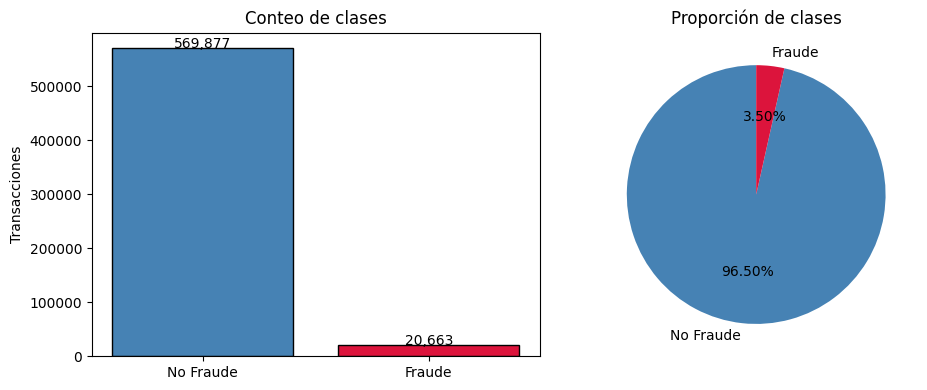

In [2]:
# --- 1. Tasa de fraude y distribución del target ---
fraud_count    = df['isFraud'].sum()
no_fraud_count = (df['isFraud'] == 0).sum()

print("=" * 45)
print("       DISTRIBUCIÓN DEL TARGET")
print("=" * 45)
print(f"  Total transacciones : {len(df):,}")
print(f"  Fraudes             : {fraud_count:,}  ({fraud_count/len(df)*100:.2f}%)")
print(f"  No fraudes          : {no_fraud_count:,}  ({no_fraud_count/len(df)*100:.2f}%)")
print("=" * 45)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['No Fraude', 'Fraude'], [no_fraud_count, fraud_count],
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Conteo de clases')
axes[0].set_ylabel('Transacciones')
for i, v in enumerate([no_fraud_count, fraud_count]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

axes[1].pie([no_fraud_count, fraud_count], labels=['No Fraude', 'Fraude'],
            colors=['steelblue', 'crimson'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Proporción de clases')
plt.tight_layout()
plt.show()

In [3]:
# --- 2. Análisis de valores nulos por grupo de features ---

# Definir grupos de features según la documentación IEEE-CIS
grupos = {
    'Transacción base'   : ['TransactionDT', 'TransactionAmt', 'ProductCD'],
    'Tarjeta (card)'     : [c for c in df.columns if c.startswith('card')],
    'Dirección (addr)'   : [c for c in df.columns if c.startswith('addr')],
    'Distancia (dist)'   : [c for c in df.columns if c.startswith('dist')],
    'Email'              : ['P_emaildomain', 'R_emaildomain'],
    'Conteo (C)'         : [c for c in df.columns if c.startswith('C') and c[1:].isdigit()],
    'Tiempo delta (D)'   : [c for c in df.columns if c.startswith('D') and c[1:].isdigit()],
    'Match (M)'          : [c for c in df.columns if c.startswith('M') and c[1:].isdigit()],
    'Vesta V1-V100'      : [c for c in df.columns if c.startswith('V') and c[1:].isdigit() and int(c[1:]) <= 100],
    'Vesta V101-V200'    : [c for c in df.columns if c.startswith('V') and c[1:].isdigit() and 101 <= int(c[1:]) <= 200],
    'Vesta V201-V339'    : [c for c in df.columns if c.startswith('V') and c[1:].isdigit() and int(c[1:]) > 200],
    'Identidad (id)'     : [c for c in df.columns if c.startswith('id_')],
    'Dispositivo'        : ['DeviceType', 'DeviceInfo'],
}

print("=== Porcentaje de nulos por grupo de features ===\n")
print(f"{'Grupo':<22} {'Features':>8} {'Nulos promedio':>15} {'Nulos máx':>12}")
print("-" * 62)

null_summary = {}
for grupo, cols in grupos.items():
    cols_exist = [c for c in cols if c in df.columns]
    if not cols_exist:
        continue
    pct_nulos = df[cols_exist].isnull().mean() * 100
    null_summary[grupo] = pct_nulos
    print(f"{grupo:<22} {len(cols_exist):>8} {pct_nulos.mean():>14.1f}% {pct_nulos.max():>11.1f}%")

=== Porcentaje de nulos por grupo de features ===

Grupo                  Features  Nulos promedio    Nulos máx
--------------------------------------------------------------
Transacción base              3            0.0%         0.0%
Tarjeta (card)                6            0.5%         1.5%
Dirección (addr)              2           11.1%        11.1%
Distancia (dist)              2           76.6%        93.6%
Email                         2           46.4%        76.8%
Conteo (C)                   14            0.0%         0.0%
Tiempo delta (D)             15           58.2%        93.4%
Match (M)                     9           49.9%        59.3%
Vesta V1-V100               100           19.2%        47.3%
Vesta V101-V200             100           51.0%        86.1%
Vesta V201-V339             139           54.5%        86.1%
Identidad (id)               38           84.8%        99.2%
Dispositivo                   2           78.0%        79.9%


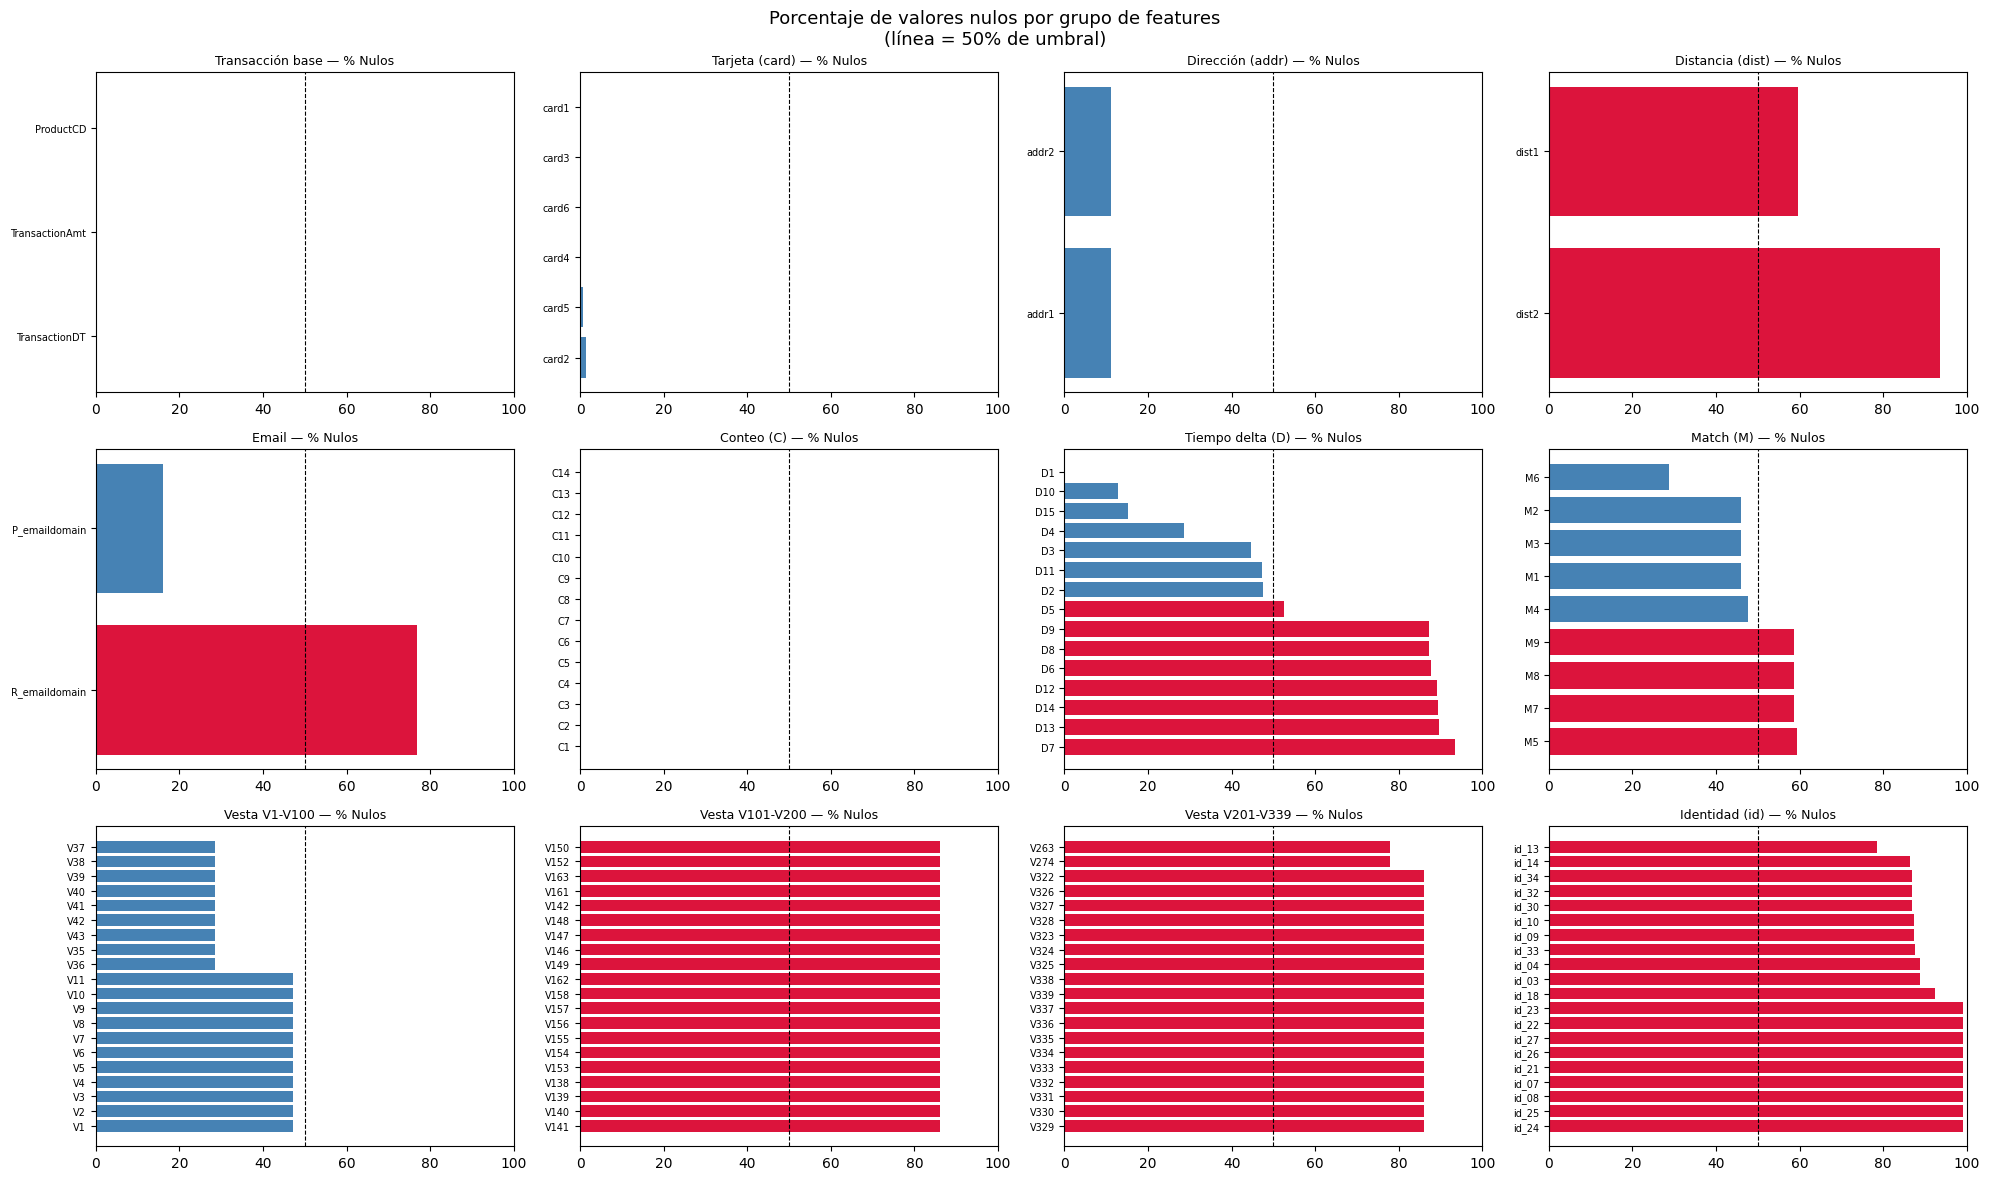

In [4]:
# --- 3. Heatmap de nulos por grupo ---
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
idx  = 0

for grupo, pct_nulos in null_summary.items():
    if len(pct_nulos) > 1 and idx < len(axes):
        top = pct_nulos.sort_values(ascending=False).head(20)
        axes[idx].barh(range(len(top)), top.values,
                       color=['crimson' if v > 50 else 'steelblue' for v in top.values])
        axes[idx].set_yticks(range(len(top)))
        axes[idx].set_yticklabels(top.index, fontsize=7)
        axes[idx].set_title(f'{grupo} — % Nulos', fontsize=9)
        axes[idx].axvline(50, color='black', linestyle='--', linewidth=0.8)
        axes[idx].set_xlim(0, 100)
        idx += 1

for i in range(idx, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Porcentaje de valores nulos por grupo de features\n(línea = 50% de umbral)', fontsize=13)
plt.tight_layout()
plt.show()

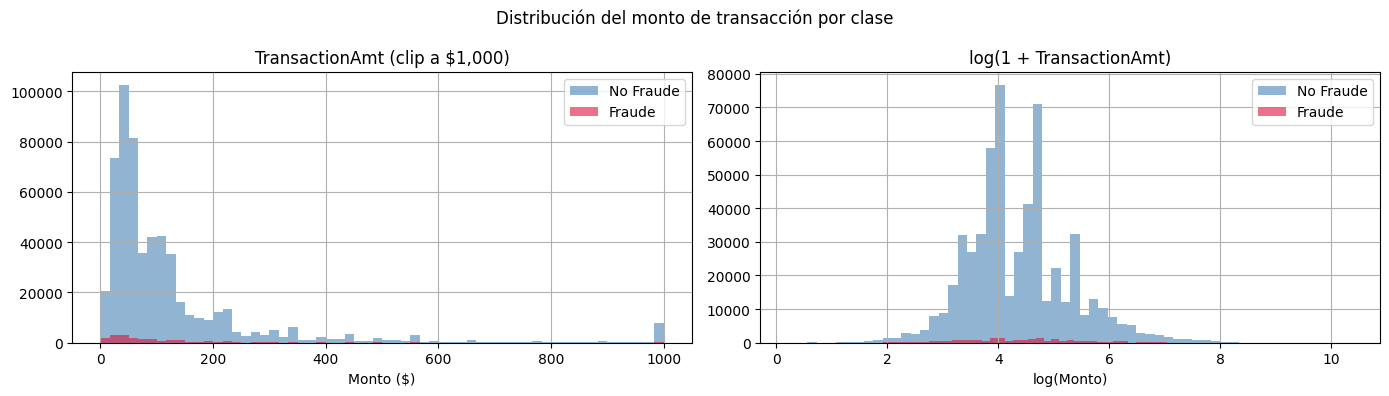


=== Estadísticas de TransactionAmt por clase ===
            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [5]:
# --- 4. Distribución de TransactionAmt por clase ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma original
df[df['isFraud'] == 0]['TransactionAmt'].clip(upper=1000).hist(
    ax=axes[0], bins=60, alpha=0.6, label='No Fraude', color='steelblue')
df[df['isFraud'] == 1]['TransactionAmt'].clip(upper=1000).hist(
    ax=axes[0], bins=60, alpha=0.6, label='Fraude',    color='crimson')
axes[0].set_title('TransactionAmt (clip a $1,000)')
axes[0].set_xlabel('Monto ($)')
axes[0].legend()

# Log-scale
np.log1p(df[df['isFraud'] == 0]['TransactionAmt']).hist(
    ax=axes[1], bins=60, alpha=0.6, label='No Fraude', color='steelblue')
np.log1p(df[df['isFraud'] == 1]['TransactionAmt']).hist(
    ax=axes[1], bins=60, alpha=0.6, label='Fraude',    color='crimson')
axes[1].set_title('log(1 + TransactionAmt)')
axes[1].set_xlabel('log(Monto)')
axes[1].legend()

plt.suptitle('Distribución del monto de transacción por clase', fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== Estadísticas de TransactionAmt por clase ===")
print(df.groupby('isFraud')['TransactionAmt'].describe().round(2))

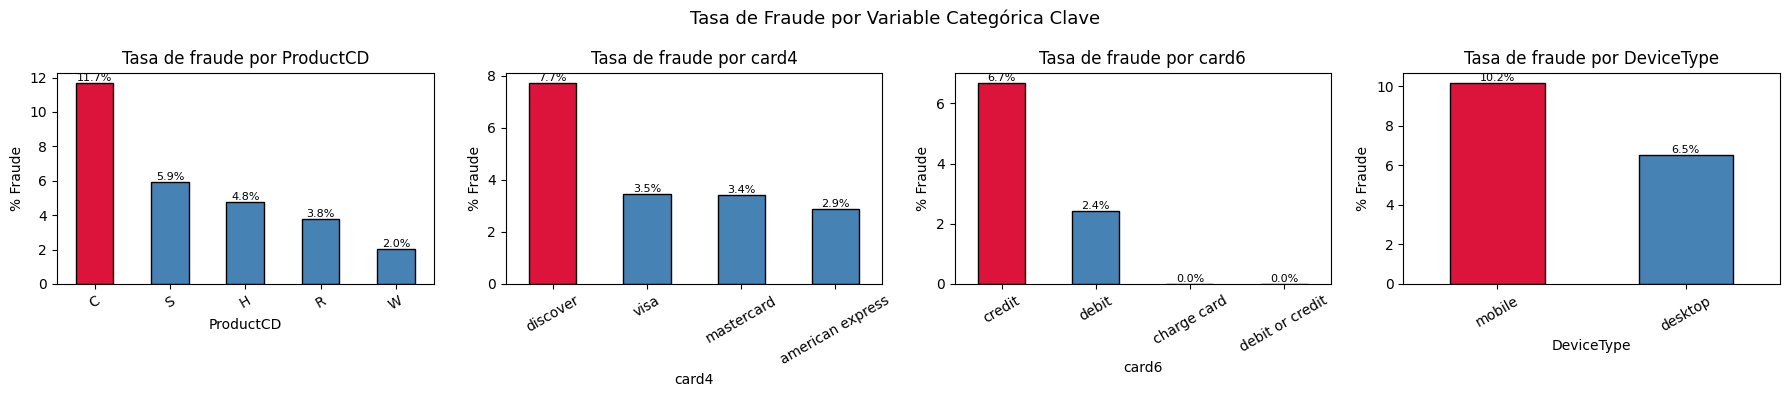


=== Chi-cuadrado — Variables categóricas ===

Feature                    Chi2      p-value  Significativa?
--------------------------------------------------------------
ProductCD              16742.17     0.00e+00            ✓ SÍ
card4                    368.90     1.45e-78            ✓ SÍ
card6                   5966.30     0.00e+00            ✓ SÍ
DeviceType             12230.17     0.00e+00            ✓ SÍ


In [6]:
# --- 5. Análisis de features categóricas clave ---
cat_key = ['ProductCD', 'card4', 'card6', 'DeviceType']
cat_key = [c for c in cat_key if c in df.columns]

fig, axes = plt.subplots(1, len(cat_key), figsize=(18, 4))

for ax, col in zip(axes, cat_key):
    fraud_rate = df.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
    colors_bar = ['crimson' if v == fraud_rate.max() else 'steelblue' for v in fraud_rate]
    fraud_rate.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='black')
    ax.set_title(f'Tasa de fraude por {col}')
    ax.set_ylabel('% Fraude')
    ax.tick_params(axis='x', rotation=30)
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.1f}%',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Tasa de Fraude por Variable Categórica Clave', fontsize=13)
plt.tight_layout()
plt.show()

# Chi-cuadrado para variables categóricas
print("\n=== Chi-cuadrado — Variables categóricas ===\n")
print(f"{'Feature':<20} {'Chi2':>10} {'p-value':>12}  {'Significativa?':>14}")
print("-" * 62)
for col in cat_key:
    tabla = pd.crosstab(df[col].fillna('NaN'), df['isFraud'])
    chi2, p, _, _ = chi2_contingency(tabla)
    sig = "✓ SÍ" if p < 0.05 else "✗ NO"
    print(f"{col:<20} {chi2:>10.2f} {p:>12.2e}  {sig:>14}")

=== Features C: media por clase (Fraude vs No Fraude) ===

     No Fraude  Fraude  Ratio F/NF
C12      3.550  18.598        5.24
C7       2.517  11.977        4.76
C8       4.561  21.243        4.66
C10      4.724  19.494        4.13
C4       3.694  15.077        4.08
C2      14.173  45.509        3.21
C1      13.315  35.536        2.67
C11      9.748  23.857        2.45
C6       8.786  16.923        1.93
C14      8.220  10.356        1.26
C13     32.814  24.968        0.76
C9       4.581   1.704        0.37
C5       5.723   1.407        0.25
C3       0.006   0.000        0.04


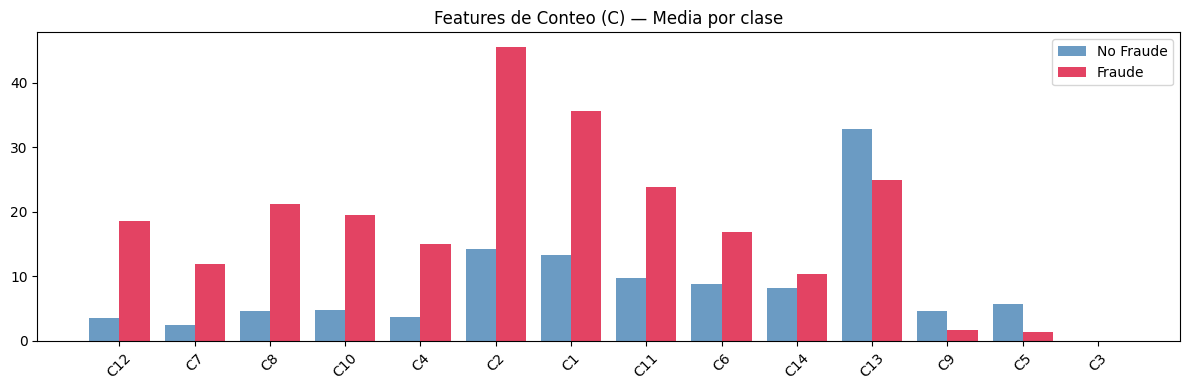

In [7]:
# --- 6. Features C (conteo) — muy informativas ---
c_cols = [c for c in df.columns if c.startswith('C') and c[1:].isdigit()]

print("=== Features C: media por clase (Fraude vs No Fraude) ===\n")
stats_c = df.groupby('isFraud')[c_cols].mean().T
stats_c.columns = ['No Fraude', 'Fraude']
stats_c['Ratio F/NF'] = (stats_c['Fraude'] / stats_c['No Fraude']).round(2)
stats_c = stats_c.sort_values('Ratio F/NF', ascending=False)
print(stats_c.round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(stats_c))
w = 0.4
ax.bar(x - w/2, stats_c['No Fraude'], w, label='No Fraude', color='steelblue', alpha=0.8)
ax.bar(x + w/2, stats_c['Fraude'],    w, label='Fraude',    color='crimson',   alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(stats_c.index, rotation=45)
ax.set_title('Features de Conteo (C) — Media por clase')
ax.legend()
plt.tight_layout()
plt.show()

Calculando importancia de features (muestra 50k)...


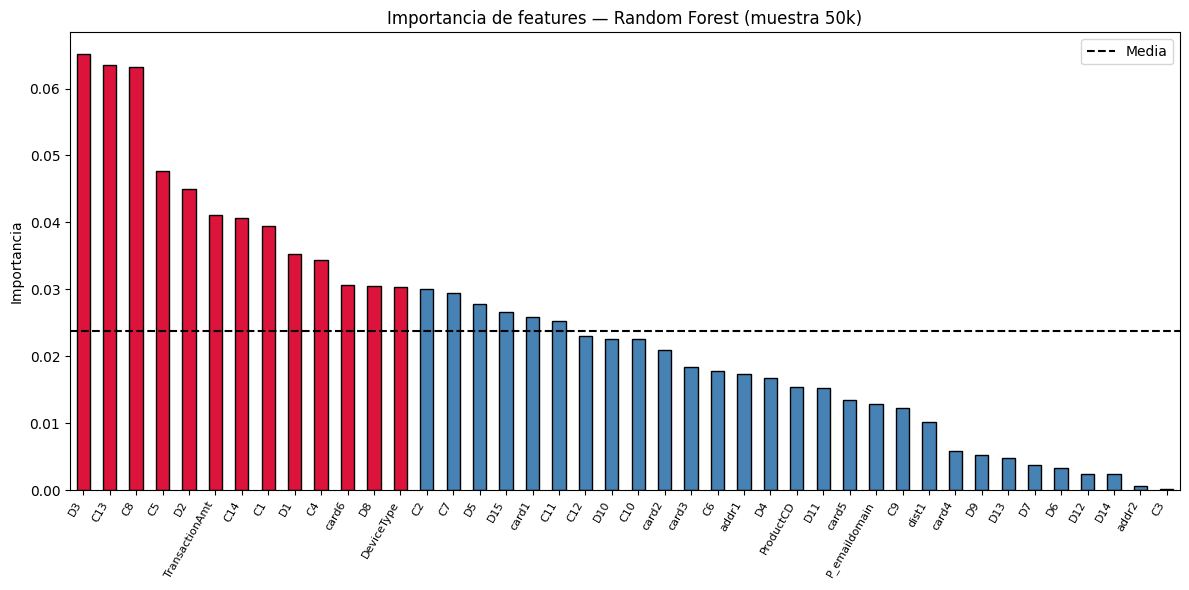


=== Top 15 features más importantes ===
D3                0.0651
C13               0.0636
C8                0.0632
C5                0.0476
D2                0.0451
TransactionAmt    0.0411
C14               0.0407
C1                0.0394
D1                0.0353
C4                0.0344
card6             0.0307
D8                0.0305
DeviceType        0.0304
C2                0.0300
C7                0.0294


In [8]:
# --- 7. Importancia preliminar con Random Forest (muestra para eficiencia) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

print("Calculando importancia de features (muestra 50k)...")

# Seleccionar features clave para análisis inicial
feat_importancia = (
    ['TransactionAmt'] +
    [c for c in df.columns if c.startswith('C') and c[1:].isdigit()] +
    [c for c in df.columns if c.startswith('D') and c[1:].isdigit()] +
    ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1'] +
    ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'DeviceType']
)
feat_importancia = [f for f in feat_importancia if f in df.columns]

df_sample = df[feat_importancia + ['isFraud']].sample(50000, random_state=42)

# Encoding de categorías
df_enc = df_sample.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

X_imp = SimpleImputer(strategy='median').fit_transform(
    df_enc.drop(columns=['isFraud']))
y_imp = df_enc['isFraud'].values

rf_imp = RandomForestClassifier(n_estimators=50, class_weight='balanced',
                                 max_depth=10, random_state=42, n_jobs=-1)
rf_imp.fit(X_imp, y_imp)

importancias = pd.Series(rf_imp.feature_importances_, index=feat_importancia)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors_imp = ['crimson' if v >= importancias.quantile(0.70) else 'steelblue'
              for v in importancias]
importancias.plot(kind='bar', color=colors_imp, edgecolor='black')
plt.axhline(importancias.mean(), color='black', linestyle='--', label='Media')
plt.title('Importancia de features — Random Forest (muestra 50k)')
plt.ylabel('Importancia')
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== Top 15 features más importantes ===")
print(importancias.head(15).round(4).to_string())

Generación y selección de características

In [9]:
# --- 1. Reload limpio y merge ---
df_trans = pd.read_csv('train_transaction.csv')
df_ident = pd.read_csv('train_identity.csv')
df = df_trans.merge(df_ident, on='TransactionID', how='left')

print(f"Dataset base: {df.shape}")

Dataset base: (590540, 434)


In [10]:
# --- 2. Ingeniería de features temporales ---
# TransactionDT = segundos desde 2017-11-30 (referencia de la competencia)
START_DATE = datetime(2017, 11, 30)

df['date']        = df['TransactionDT'].apply(lambda x: START_DATE + timedelta(seconds=x))
df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek   # 0=lunes, 6=domingo
df['day_of_month']= df['date'].dt.day
df['month']       = df['date'].dt.month
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_night']    = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
df = df.drop(columns=['date'])

print("Features temporales creadas:", ['hour','day_of_week','day_of_month','month','is_weekend','is_night'])

Features temporales creadas: ['hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_night']


In [11]:
# --- 3. Features de monto ---
df['log_amount']     = np.log1p(df['TransactionAmt'])
df['amount_cents']   = (df['TransactionAmt'] % 1).round(2)   # parte decimal (0.00 = número redondo)
df['is_round_amount']= (df['amount_cents'] == 0.0).astype(int)

print("\n=== Tasa de fraude por monto redondo ===")
print(df.groupby('is_round_amount')['isFraud'].mean().round(4) * 100)


=== Tasa de fraude por monto redondo ===
is_round_amount
0    3.41
1    3.58
Name: isFraud, dtype: float64


In [12]:
# --- 4. Features de email ---
def limpiar_dominio(dominio):
    if pd.isnull(dominio):
        return 'desconocido'
    partes = dominio.split('.')
    return partes[-1] if len(partes) >= 2 else dominio

df['P_email_suffix'] = df['P_emaildomain'].apply(limpiar_dominio)
df['R_email_suffix'] = df['R_emaildomain'].apply(limpiar_dominio)
df['same_email']     = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)
df['P_email_missing']= df['P_emaildomain'].isnull().astype(int)
df['R_email_missing']= df['R_emaildomain'].isnull().astype(int)

print("\n=== Tasa de fraude: ¿mismo email comprador/receptor? ===")
print(df.groupby('same_email')['isFraud'].mean().round(4) * 100)


=== Tasa de fraude: ¿mismo email comprador/receptor? ===
same_email
0    2.21
1    9.65
Name: isFraud, dtype: float64


In [13]:
# --- 5. Features de tarjeta ---
# card1 = identificador de la tarjeta (proxy del cliente)
df['card_id'] = df['card1'].astype(str) + '_' + df['card2'].astype(str)

# Frecuencia de uso de cada tarjeta (tarjetas con muchas transacciones pueden ser robadas)
card_freq = df['card1'].value_counts().rename('card1_freq')
df = df.join(card_freq, on='card1')

# Monto medio por tarjeta (desviación del monto habitual de esa tarjeta)
card_mean_amt = df.groupby('card1')['TransactionAmt'].transform('mean')
df['card1_amt_diff'] = df['TransactionAmt'] - card_mean_amt

print("\nFeatures de tarjeta creadas: card_id, card1_freq, card1_amt_diff")
print(df[['card1_freq', 'card1_amt_diff', 'isFraud']].groupby('isFraud').mean().round(2))


Features de tarjeta creadas: card_id, card1_freq, card1_amt_diff
         card1_freq  card1_amt_diff
isFraud                            
0           2535.85           -0.85
1           2334.68           23.51


In [14]:
# --- 6. Features de dispositivo ---
def clasificar_dispositivo(info):
    if pd.isnull(info):
        return 'desconocido'
    info = info.lower()
    if 'samsung'  in info: return 'samsung'
    if 'iphone'   in info or 'ios' in info: return 'apple'
    if 'windows'  in info: return 'windows'
    if 'macos'    in info or 'mac' in info: return 'apple_desktop'
    if 'android'  in info: return 'android_otro'
    return 'otro'

df['device_brand'] = df['DeviceInfo'].apply(clasificar_dispositivo)

print("\n=== Tasa de fraude por marca de dispositivo ===")
print(df.groupby('device_brand')['isFraud'].mean().sort_values(ascending=False).round(4) * 100)


=== Tasa de fraude por marca de dispositivo ===
device_brand
otro             10.44
samsung           8.17
windows           6.55
apple             6.27
android_otro      3.66
desconocido       2.55
apple_desktop     2.21
Name: isFraud, dtype: float64


In [15]:
# --- 7. Eliminar columnas con >80% nulos ---
umbral_nulos = 0.80
pct_nulos    = df.isnull().mean()
cols_muchos_nulos = pct_nulos[pct_nulos > umbral_nulos].index.tolist()

print(f"Columnas eliminadas por >80% nulos: {len(cols_muchos_nulos)}")
print(f"Primeras 20: {cols_muchos_nulos[:20]}")

df = df.drop(columns=cols_muchos_nulos)
print(f"\nShape tras eliminación: {df.shape}")

Columnas eliminadas por >80% nulos: 74
Primeras 20: ['dist2', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14', 'V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149']

Shape tras eliminación: (590540, 378)


In [16]:
# --- 8. Encoding de variables categóricas ---
from sklearn.preprocessing import LabelEncoder

# Columnas a eliminar (identificadores, no útiles para el modelo)
cols_eliminar = ['TransactionID', 'TransactionDT', 'TransactionAmt',
                 'P_emaildomain', 'R_emaildomain', 'card_id', 'DeviceInfo']
cols_eliminar = [c for c in cols_eliminar if c in df.columns]
df = df.drop(columns=cols_eliminar)

# Encoding de categorías restantes
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Variables categóricas a encodear ({len(cat_cols)}): {cat_cols}")

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

print(f"\nShape tras encoding: {df.shape}")

Variables categóricas a encodear (26): ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'P_email_suffix', 'R_email_suffix', 'device_brand']

Shape tras encoding: (590540, 371)


In [17]:
# --- 9. Imputación de valores nulos ---
from sklearn.impute import SimpleImputer

X_cols = [c for c in df.columns if c != 'isFraud']
y      = df['isFraud'].values

imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(df[X_cols])

print(f"Shape final antes de selección: {X_imp.shape}")
print(f"Nulos restantes: {np.isnan(X_imp).sum()}")

Shape final antes de selección: (590540, 370)
Nulos restantes: 0


In [18]:
# --- 10. Selección de features con LightGBM o Random Forest ---
try:
    import lightgbm as lgb
    USE_LGB = True
    print("Usando LightGBM para selección (más rápido)")
except ImportError:
    USE_LGB = False
    print("LightGBM no disponible, usando Random Forest")

from sklearn.feature_selection import SelectFromModel

if USE_LGB:
    selector_model = lgb.LGBMClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1
    )
else:
    selector_model = RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        max_depth=12, random_state=42, n_jobs=-1
    )

selector = SelectFromModel(selector_model, threshold='mean')
selector.fit(X_imp, y)

selected_mask     = selector.get_support()
selected_features = np.array(X_cols)[selected_mask].tolist()
X_final           = X_imp[:, selected_mask]

print(f"\nFeatures seleccionadas: {len(selected_features)} de {len(X_cols)}")

Usando LightGBM para selección (más rápido)

Features seleccionadas: 72 de 370


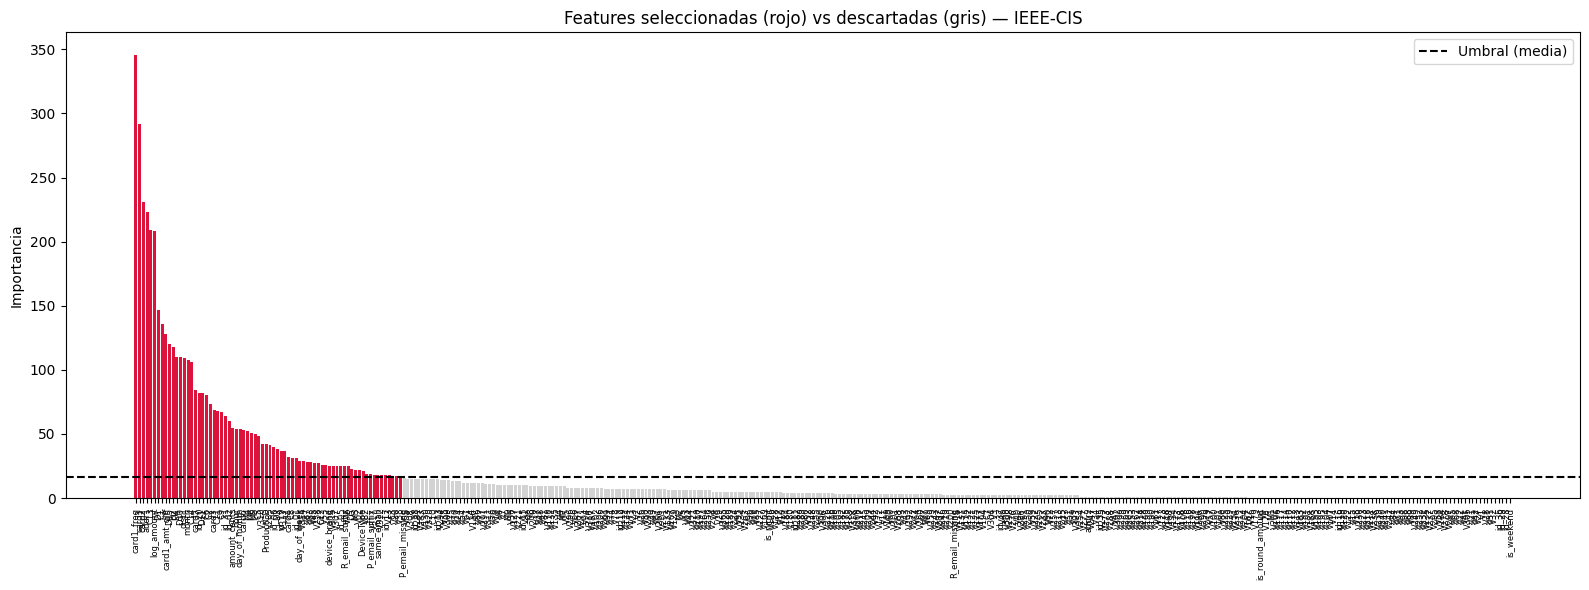


=== Top 20 features seleccionadas ===
card1_freq        346
card1             292
card2             231
addr1             223
C13               209
log_amount        208
D1                147
C1                136
card1_amt_diff    128
D15               120
D2                118
D10               110
D4                110
dist1             109
month             108
C14               106
card5              84
D11                82
id_20              82
C6                 80


In [19]:
# --- 11. Visualización: features seleccionadas vs descartadas ---
importancias_fin = pd.Series(
    selector.estimator_.feature_importances_,
    index=X_cols
).sort_values(ascending=False)

colors_fin = ['crimson' if f in selected_features else 'lightgray'
              for f in importancias_fin.index]

plt.figure(figsize=(16, 6))
plt.bar(range(len(importancias_fin)), importancias_fin.values, color=colors_fin)
plt.axhline(importancias_fin.mean(), color='black', linestyle='--', label='Umbral (media)')
plt.title('Features seleccionadas (rojo) vs descartadas (gris) — IEEE-CIS')
plt.ylabel('Importancia')
plt.xticks(range(len(importancias_fin)), importancias_fin.index,
           rotation=90, fontsize=6)
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== Top 20 features seleccionadas ===")
print(importancias_fin[selected_features].sort_values(ascending=False).head(20).round(5).to_string())

In [20]:
# --- 12. Resumen final ---
y_final = y

print("=" * 55)
print("       RESUMEN FINAL — SELECCIÓN DE FEATURES")
print("=" * 55)
print(f"  Features originales (trans + identity) : {df_trans.shape[1] + df_ident.shape[1] - 1}")
print(f"  Tras eliminar >80% nulos               : {len(X_cols)}")
print(f"  Features seleccionadas para el MLP     : {len(selected_features)}")
print(f"  Shape X_final                          : {X_final.shape}")
print(f"  Shape y_final                          : {y_final.shape}")
print(f"  Tasa de fraude                         : {y_final.mean()*100:.2f}%")
print("=" * 55)
print("\nFeatures finales para el modelo MLP:")
for i, f in enumerate(importancias_fin[selected_features]
                       .sort_values(ascending=False).index, 1):
    print(f"  {i:2}. {f}")

       RESUMEN FINAL — SELECCIÓN DE FEATURES
  Features originales (trans + identity) : 434
  Tras eliminar >80% nulos               : 370
  Features seleccionadas para el MLP     : 72
  Shape X_final                          : (590540, 72)
  Shape y_final                          : (590540,)
  Tasa de fraude                         : 3.50%

Features finales para el modelo MLP:
   1. card1_freq
   2. card1
   3. card2
   4. addr1
   5. C13
   6. log_amount
   7. D1
   8. C1
   9. card1_amt_diff
  10. D15
  11. D2
  12. D10
  13. D4
  14. dist1
  15. month
  16. C14
  17. card5
  18. D11
  19. id_20
  20. C6
  21. C2
  22. card3
  23. C11
  24. C9
  25. id_31
  26. id_02
  27. amount_cents
  28. day_of_month
  29. hour
  30. card6
  31. M4
  32. M6
  33. M5
  34. C5
  35. V310
  36. ProductCD
  37. V285
  38. id_06
  39. D3
  40. id_19
  41. V313
  42. card4
  43. C8
  44. id_01
  45. day_of_week
  46. V314
  47. V83
  48. V87
  49. V258
  50. V45
  51. C12
  52. V53
  53. V76
  54. id_